In [ ]:
# Installing necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# SaANN libraries
from saann.models import SequentialModel
from saann.losses import MSE

In [29]:
# XOR dataset setup
X_train = np.array([[0,0], [0,1], [1,0], [1,1]])
y_train = np.array([[0], [1], [1], [0]])
X_test = np.array([[1,0], [0,0], [1,1], [0,1]])
y_test = np.array([[1], [0], [0], [1]])

In [30]:
# Initialize model
model = SequentialModel()

In [31]:
# Define layer specifications: (input_size, neurons, activation, initialization)
layer_info = [
    (X_train.shape[1], 10, "relu", "he"),
    (10, 1, "linear", "he")
]

In [32]:
# Build and train
model.construct(layer_info, learning_rate=0.001)
final_pred = model.fit(X_train, y_train, epochs=1000, batch_size=1)

Training for 1000 Epochs with learning rate: 0.001
Epoch    1/1000, Loss (MSE): 0.74958
Epoch  100/1000, Loss (MSE): 0.08822
Epoch  200/1000, Loss (MSE): 0.05007
Epoch  300/1000, Loss (MSE): 0.03307
Epoch  400/1000, Loss (MSE): 0.02275
Epoch  500/1000, Loss (MSE): 0.01628
Epoch  600/1000, Loss (MSE): 0.01182
Epoch  700/1000, Loss (MSE): 0.00863
Epoch  800/1000, Loss (MSE): 0.00632
Epoch  900/1000, Loss (MSE): 0.00462
Epoch 1000/1000, Loss (MSE): 0.00338

Final MSE Loss on training data: 0.00332


In [35]:
print("\n--- After Training ---")
print("Input | Train Target | Predicted Target | Rounded Prediction")
for i in range(X_train.shape[0]):
    pred_val = final_pred[i][0]
    rounded_pred = int(np.round(pred_val))
    print(f"{X_train[i]} | {y_train[i][0]:12d} | {pred_val:16.2f} | {rounded_pred}")


--- After Training ---
Input | Train Target | Predicted Target | Rounded Prediction
[0 0] |            0 |             0.07 | 0
[0 1] |            1 |             0.95 | 1
[1 0] |            1 |             0.95 | 1
[1 1] |            0 |             0.05 | 0


In [38]:
# Predict
y_pred = model.predict(X_test)


Loss (MSE) on testing data: 0.0033


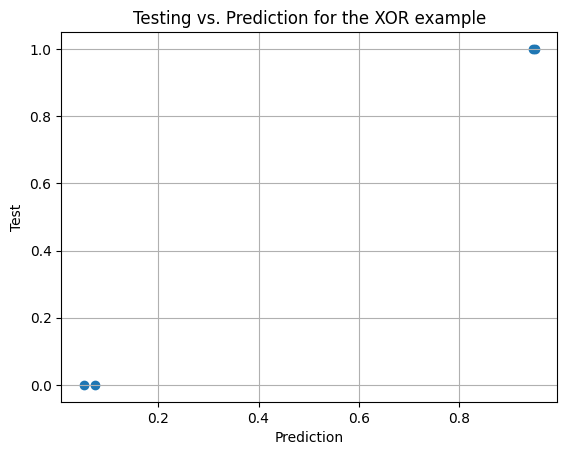

In [43]:
# Show prediction with MSE
mse = MSE(y_true=y_test, y_pred=y_pred)
print(f"\nLoss (MSE) on testing data: {mse:.2g}")
plt.scatter(x = y_pred, y = y_test)
plt.title("Testing vs. Prediction for the XOR example")
plt.xlabel("Prediction")
plt.ylabel("Test")
plt.grid()
plt.show()